<a href="https://colab.research.google.com/github/RaniellyPatricia/previsao-conversao-leads-cursos/blob/main/notebooks/03_analise_exploratoria_mvp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 - Análise exploratória dos leads

Este notebook tem como objetivo analisar padrões de conversão dos leads, comparando canais, perfis, comportamentos e diferenças entre leads convertidos e não convertidos.

A análise faz parte do MVP 1 do projeto e servirá como base para definição dos KPIs e construção do dashboard em Power BI.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

Saving leads_tratados_mvp1.csv to leads_tratados_mvp1 (1).csv


In [11]:
df = pd.read_csv("leads_tratados_mvp1.csv")

df.head()

,id_do_prospect,numero_do_lead,origem_do_lead,fonte_do_lead,nao_enviar_e-mail,convertido,total_de_visitas,tempo_total_no_site,visualizacoes_de_pagina_por_visita,ultima_atividade,...,tags,qualidade_do_lead,perfil_do_lead,cidade,indice_de_atividade_assimetrica,indice_de_perfil_assimetrico,pontuacao_de_atividade_assimetrica,pontuacao_de_perfil_assimetrico,copia_gratuita_de_mastering_the_interview,ultima_atividade_relevante
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Chat Olark,Não,0,0.0,0,0.0,Página Visitada no Site,...,Interessado em outros cursos,Baixa Relevância,Não informado,Não informado,02.Médio,02.Médio,15.0,15.0,Não,Modificado
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Busca Orgânica,Não,0,5.0,674,2.5,E-mail Aberto,...,Chamando,Não informado,Não informado,Não informado,02.Médio,02.Médio,15.0,15.0,Não,E-mail Aberto
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Envio por Landing Page,Tráfego Direto,Não,1,2.0,1532,2.0,E-mail Aberto,...,Retornará após ler o e-mail,Talvez,Lead Potencial,Mumbai,02.Médio,01.Alto,14.0,20.0,Sim,E-mail Aberto
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Envio por Landing Page,Tráfego Direto,Não,0,1.0,305,1.0,Inalcançável,...,Chamando,Incerto,Não informado,Mumbai,02.Médio,01.Alto,13.0,17.0,Não,Modificado
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Envio por Landing Page,Google,Não,1,2.0,1428,1.0,Convertido em Lead,...,Retornará após ler o e-mail,Talvez,Não informado,Mumbai,02.Médio,01.Alto,15.0,18.0,Não,Modificado


In [12]:
df_eda = df.copy()
alvo = "convertido"


In [13]:
print(f"Linhas: {df_eda.shape[0]}")
print(f"Colunas: {df_eda.shape[1]}")
print(f"Valores nulos: {df_eda.isnull().sum().sum()}")
print(f"Linhas duplicadas: {df_eda.duplicated().sum()}")

print("\nValores da variável-alvo:")
print(df_eda[alvo].value_counts())

Linhas: 9240
Colunas: 25
Valores nulos: 0
Linhas duplicadas: 0

Valores da variável-alvo:
convertido
0    5679
1    3561
Name: count, dtype: int64


In [14]:
total_leads = df_eda[alvo].count()
total_convertidos = df_eda[alvo].sum()
taxa_conversao = df_eda[alvo].mean() * 100

print(f"Total de leads analisados: {total_leads}")
print(f"Total de leads convertidos: {total_convertidos}")
print(f"Taxa geral de conversão: {taxa_conversao:.2f}%")

Total de leads analisados: 9240
Total de leads convertidos: 3561
Taxa geral de conversão: 38.54%


In [15]:
def analisar_categoria(df, coluna, alvo):
    tabela = (
        df.groupby(coluna, dropna=False)
        .agg(
            total_leads=(alvo, "count"),
            convertidos=(alvo, "sum"),
            taxa_conversao=(alvo, "mean")
        )
        .reset_index()
    )

    tabela["taxa_conversao"] = (tabela["taxa_conversao"] * 100).round(2)
    tabela["participacao_na_base"] = (
        tabela["total_leads"] / tabela["total_leads"].sum() * 100
    ).round(2)

    tabela = tabela.sort_values(
        by="taxa_conversao",
        ascending=False
    )

    return tabela

In [16]:
conversao_origem = analisar_categoria(
    df=df_eda,
    coluna="origem_do_lead",
    alvo=alvo
)

conversao_origem

,origem_do_lead,total_leads,convertidos,taxa_conversao,participacao_na_base
2,Formulário Rápido de Cadastro,1,1,100.00,0.01
3,Formulário de Cadastro de Lead,718,664,92.48,7.77
1,Envio por Landing Page,4886,1768,36.19,52.88
0,API,3580,1115,31.15,38.74
4,Importação de Lead,55,13,23.64,0.60


### Insight — Conversão por origem do lead

A análise por origem mostrou diferenças importantes entre os canais de entrada dos leads. A origem **Formulário de Cadastro de Lead** apresentou a maior taxa de conversão entre as origens com volume relevante, com **92,48% de conversão** em **718 leads**, indicando forte potencial de qualificação.

Já a origem **Envio por Landing Page** concentrou o maior volume da base, representando **52,88% dos leads**, mas apresentou taxa de conversão de **36,19%**, próxima da média geral. Isso sugere que landing pages são importantes para aquisição em escala, mas podem exigir ações de qualificação e nutrição.

A origem **API** também possui alto volume, com **38,74% da base**, porém apresentou taxa de conversão menor, de **31,15%**, indicando oportunidade de investigação sobre a qualidade ou o estágio desses leads.

A origem **Formulário Rápido de Cadastro** teve 100% de conversão, mas com apenas 1 lead, portanto não deve ser usada como evidência forte para decisão.

In [17]:
conversao_fonte = analisar_categoria(
    df=df_eda,
    coluna="fonte_do_lead",
    alvo=alvo
)

conversao_fonte.head(15)

,fonte_do_lead,total_leads,convertidos,taxa_conversao,participacao_na_base
6,Chat ao Vivo,2,2,100.00,0.02
12,NC_EDM,1,1,100.00,0.01
20,WeLearn,1,1,100.00,0.01
16,Site Welingak,142,140,98.59,1.54
15,Referência,534,490,91.76,5.78
13,Não informado,36,29,80.56,0.39
7,Clique para Ligar,4,3,75.00,0.04
11,Mídias Sociais,2,1,50.00,0.02
10,Google,2873,1147,39.92,31.09
3,Busca Orgânica,1154,436,37.78,12.49


In [18]:
conversao_fonte_relevante = conversao_fonte[
    conversao_fonte["total_leads"] >= 50
]

conversao_fonte_relevante.sort_values(
    by="taxa_conversao",
    ascending=False
)

,fonte_do_lead,total_leads,convertidos,taxa_conversao,participacao_na_base
16,Site Welingak,142,140,98.59,1.54
15,Referência,534,490,91.76,5.78
10,Google,2873,1147,39.92,31.09
3,Busca Orgânica,1154,436,37.78,12.49
19,Tráfego Direto,2543,818,32.17,27.52
5,Chat Olark,1755,448,25.53,18.99
17,Sites de Referência,125,31,24.80,1.35
9,Facebook,55,13,23.64,0.60


### Insight — Conversão por fonte do lead

Após filtrar fontes com pelo menos 50 leads, a análise mostrou diferenças relevantes de desempenho entre os canais de aquisição.

A fonte **Referência** apresentou uma das melhores combinações entre volume e taxa de conversão, com **534 leads** e **91,76% de conversão**, sugerindo que leads vindos por indicação ou referência chegam mais qualificados e próximos da decisão de matrícula.

A fonte **Site Welingak** apresentou a maior taxa de conversão, com **98,59%**, porém representa apenas **1,54% da base**. Por isso, apesar do desempenho alto, deve ser analisada com cautela e investigada como possível canal altamente qualificado.

O **Google** foi a principal fonte em volume, representando **31,09% da base**, com **2.873 leads** e taxa de conversão de **39,92%**, ligeiramente acima da média geral de **38,54%**. Isso indica que o canal combina escala com desempenho razoável.

Por outro lado, **Chat Olark** e **Tráfego Direto** apresentaram alto volume, mas taxas de conversão inferiores à média geral. Esses canais podem representar oportunidades de melhoria na qualificação, nutrição ou abordagem comercial.

In [19]:
conversao_ocupacao = analisar_categoria(
    df=df_eda,
    coluna="ocupacao_atual",
    alvo=alvo
)

conversao_ocupacao

,ocupacao_atual,total_leads,convertidos,taxa_conversao,participacao_na_base
1,Dona de Casa,10,10,100.00,0.11
6,Profissional Empregado,706,647,91.64,7.64
2,Empresário,8,5,62.50,0.09
5,Outro,16,10,62.50,0.17
0,Desempregado,5600,2441,43.59,60.61
3,Estudante,210,78,37.14,2.27
4,Não informado,2690,370,13.75,29.11


In [20]:
conversao_qualidade = analisar_categoria(
    df=df_eda,
    coluna="qualidade_do_lead",
    alvo=alvo
)

conversao_qualidade

,qualidade_do_lead,total_leads,convertidos,taxa_conversao,participacao_na_base
0,Alta Relevância,637,603,94.66,6.89
1,Baixa Relevância,583,477,81.82,6.31
5,Talvez,1560,1179,75.58,16.88
2,Incerto,1092,266,24.36,11.82
4,Não informado,4767,1024,21.48,51.59
3,Muito Baixa,601,12,2.00,6.50


In [21]:
conversao_perfil = analisar_categoria(
    df=df_eda,
    coluna="perfil_do_lead",
    alvo=alvo
)

conversao_perfil

,perfil_do_lead,total_leads,convertidos,taxa_conversao,participacao_na_base
2,Estudante de Dupla Especialização,20,20,100.00,0.22
1,Estudante Lateral,24,23,95.83,0.26
3,Lead Potencial,1613,1267,78.55,17.46
5,Outros Leads,487,180,36.96,5.27
4,Não informado,6855,2062,30.08,74.19
0,Aluno da SomeSchool,241,9,3.73,2.61


In [22]:
variaveis_comportamento = [
    "total_de_visitas",
    "tempo_total_no_site",
    "visualizacoes_de_pagina_por_visita"
]

comparacao_medias = df_eda.groupby(alvo)[variaveis_comportamento].mean().T

comparacao_medias.columns = ["media_nao_convertidos", "media_convertidos"]

comparacao_medias["diferenca"] = (
    comparacao_medias["media_convertidos"] -
    comparacao_medias["media_nao_convertidos"]
)

comparacao_medias["diferenca_percentual"] = (
    comparacao_medias["diferenca"] /
    comparacao_medias["media_nao_convertidos"] * 100
).round(2)

comparacao_medias

,media_nao_convertidos,media_convertidos,diferenca,diferenca_percentual
total_de_visitas,3.307977,3.531592,0.223615,6.76
tempo_total_no_site,330.404473,738.546757,408.142284,123.53
visualizacoes_de_pagina_por_visita,2.353022,2.287543,-0.065479,-2.78


### Insight — Comportamento dos leads convertidos e não convertidos

A comparação entre leads convertidos e não convertidos mostrou que o **tempo total no site** é o comportamento com maior diferença entre os grupos. Leads convertidos permaneceram, em média, **738,55** no site, enquanto leads não convertidos permaneceram **330,40**, uma diferença de **123,53%**.

Esse resultado sugere que maior tempo de navegação pode estar associado a maior intenção de matrícula ou compra, tornando essa variável relevante para análises futuras e para o score de priorização do MVP 2.

Já o **total de visitas** apresentou diferença menor, com média de **3,53** visitas para convertidos e **3,31** para não convertidos. A variável **visualizações de página por visita** praticamente não diferenciou os grupos, indicando menor relevância para explicar conversão nesta etapa.

In [23]:
conversao_ultima_atividade = analisar_categoria(
    df=df_eda,
    coluna="ultima_atividade",
    alvo=alvo
)

conversao_ultima_atividade.head(15)

,ultima_atividade,total_leads,convertidos,taxa_conversao,participacao_na_base
0,Abordado Diretamente,9,9,100.00,0.10
5,E-mail Marcado como Spam,2,2,100.00,0.02
14,Reinscrito em E-mails,1,1,100.00,0.01
6,E-mail Recebido,2,2,100.00,0.02
12,Não informado,103,81,78.64,1.11
16,Teve Conversa por Telefone,30,22,73.33,0.32
15,SMS Enviado,2745,1727,62.91,29.71
4,E-mail Aberto,3437,1253,36.46,37.20
9,Inalcançável,93,31,33.33,1.01
11,Link do E-mail Clicado,267,73,27.34,2.89


In [24]:
conversao_ultima_atividade_relevante = analisar_categoria(
    df=df_eda,
    coluna="ultima_atividade_relevante",
    alvo=alvo
)

conversao_ultima_atividade_relevante.head(15)

,ultima_atividade_relevante,total_leads,convertidos,taxa_conversao,participacao_na_base
0,Abordado Diretamente,1,1,100.00,0.01
4,E-mail Marcado como Spam,2,2,100.00,0.02
5,E-mail Recebido,1,1,100.00,0.01
13,Reinscrito em E-mails,1,1,100.00,0.01
15,Teve Conversa por Telefone,14,13,92.86,0.15
14,SMS Enviado,2172,1508,69.43,23.51
8,Inalcançável,32,22,68.75,0.35
3,E-mail Aberto,2827,1044,36.93,30.60
2,Descadastrado,47,14,29.79,0.51
12,Página Visitada no Site,318,93,29.25,3.44


In [25]:
conversao_especializacao = analisar_categoria(
    df=df_eda,
    coluna="especializacao",
    alvo=alvo
)

conversao_especializacao.head(15)

,especializacao,total_leads,convertidos,taxa_conversao,participacao_na_base
12,Gestão em Saúde,159,79,49.69,1.72
1,"Bancos, Investimentos e Seguros",338,167,49.41,3.66
7,Gestão de Marketing,838,408,48.69,9.07
8,Gestão de Operações,503,238,47.32,5.44
10,Gestão de Recursos Humanos,848,388,45.75,9.18
4,Gestão Financeira,976,436,44.67,10.56
0,Administração de Empresas,403,179,44.42,4.36
5,Gestão da Cadeia de Suprimentos,349,151,43.27,3.78
17,Rural e Agronegócio,73,31,42.47,0.79
6,Gestão de Hospitalidade,114,48,42.11,1.23


In [26]:
comparacao_medianas = df_eda.groupby(alvo)[variaveis_comportamento].median().T

comparacao_medianas.columns = ["mediana_nao_convertidos", "mediana_convertidos"]

comparacao_medianas["diferenca"] = (
    comparacao_medianas["mediana_convertidos"] -
    comparacao_medianas["mediana_nao_convertidos"]
)

comparacao_medianas["diferenca_percentual"] = (
    comparacao_medianas["diferenca"] /
    comparacao_medianas["mediana_nao_convertidos"] * 100
).round(2)

comparacao_medianas

,mediana_nao_convertidos,mediana_convertidos,diferenca,diferenca_percentual
total_de_visitas,3.0,3.0,0.0,0.0
tempo_total_no_site,179.0,832.0,653.0,364.8
visualizacoes_de_pagina_por_visita,2.0,2.0,0.0,0.0


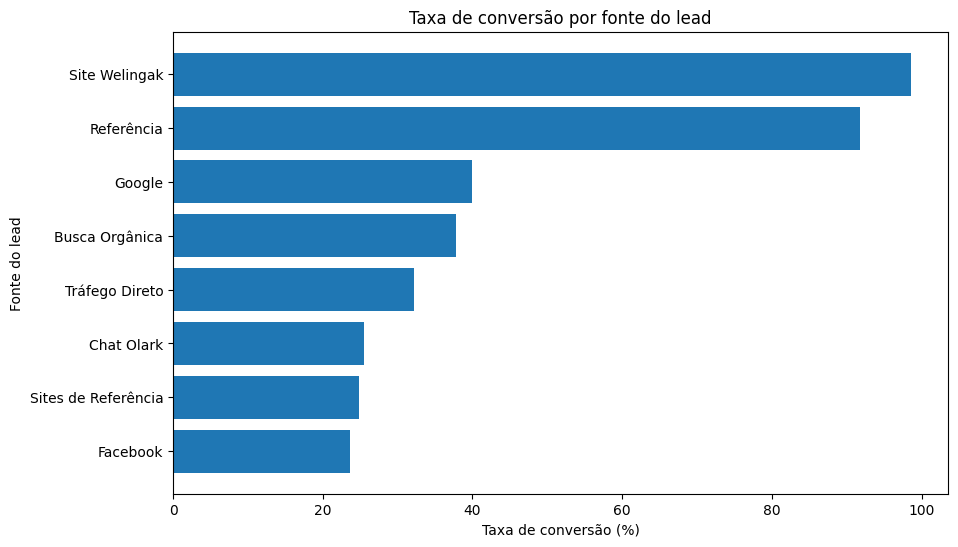

In [27]:
import matplotlib.pyplot as plt

top_fontes = conversao_fonte_relevante.sort_values(
    by="taxa_conversao",
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.barh(top_fontes["fonte_do_lead"], top_fontes["taxa_conversao"])
plt.xlabel("Taxa de conversão (%)")
plt.ylabel("Fonte do lead")
plt.title("Taxa de conversão por fonte do lead")
plt.gca().invert_yaxis()
plt.show()

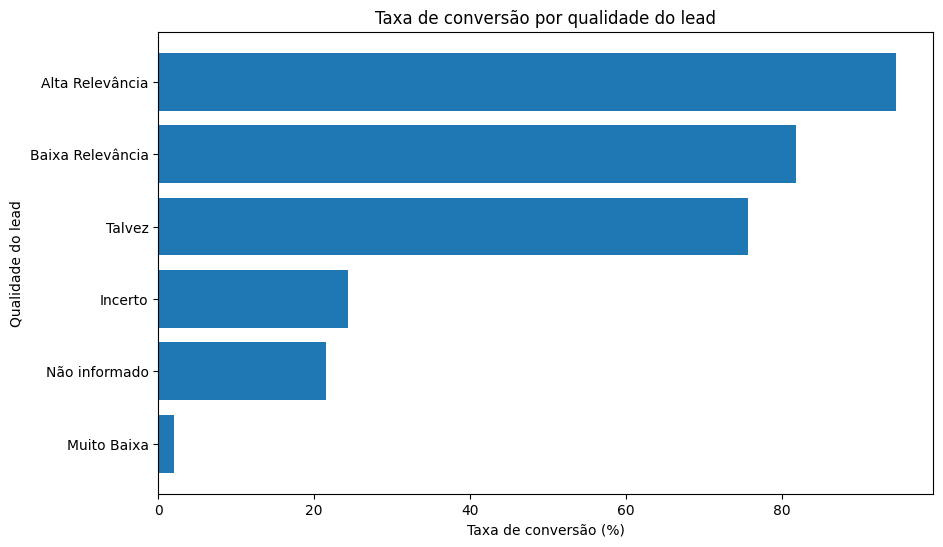

In [28]:
qualidade_plot = conversao_qualidade.sort_values(
    by="taxa_conversao",
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.barh(qualidade_plot["qualidade_do_lead"], qualidade_plot["taxa_conversao"])
plt.xlabel("Taxa de conversão (%)")
plt.ylabel("Qualidade do lead")
plt.title("Taxa de conversão por qualidade do lead")
plt.gca().invert_yaxis()
plt.show()

<Figure size 800x600 with 0 Axes>

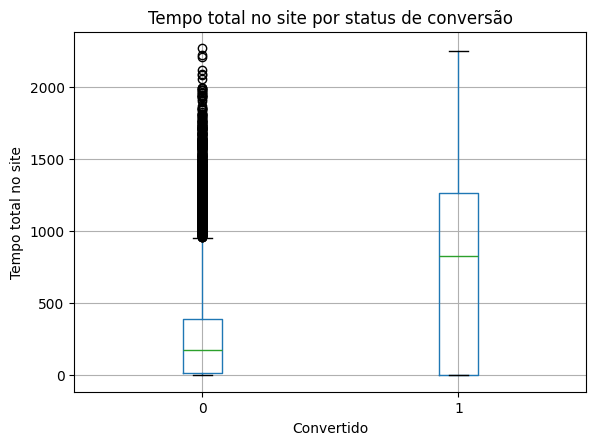

In [29]:
plt.figure(figsize=(8, 6))
df_eda.boxplot(
    column="tempo_total_no_site",
    by=alvo
)

plt.title("Tempo total no site por status de conversão")
plt.suptitle("")
plt.xlabel("Convertido")
plt.ylabel("Tempo total no site")
plt.show()

## Principais insights do MVP 1

1. A taxa geral de conversão da base foi de **38,54%**, indicando que aproximadamente 4 em cada 10 leads analisados realizaram conversão.

2. A origem **Formulário de Cadastro de Lead** apresentou alta taxa de conversão, com **92,48%**, sugerindo que esse tipo de entrada pode trazer leads mais qualificados.

3. Entre as fontes com volume relevante, **Referência** e **Site Welingak** apresentaram as maiores taxas de conversão. Já o **Google** se destacou pelo alto volume e taxa ligeiramente acima da média geral.

4. A variável **qualidade_do_lead** mostrou forte relação com conversão. Leads classificados como **Alta Relevância** apresentaram taxa de conversão muito superior aos leads de **Muito Baixa** qualidade.

5. O **tempo total no site** foi o comportamento que mais diferenciou convertidos e não convertidos. A mediana dos convertidos foi muito superior à dos não convertidos, indicando que maior tempo de navegação pode ser um sinal relevante de intenção.

6. Atividades como **SMS Enviado** apareceram associadas a taxas de conversão acima da média, indicando que determinados tipos de interação podem ter maior relação com avanço no funil.

In [30]:
conversao_fonte_relevante.to_csv("conversao_por_fonte.csv", index=False)
conversao_origem.to_csv("conversao_por_origem.csv", index=False)
conversao_qualidade.to_csv("conversao_por_qualidade.csv", index=False)
conversao_perfil.to_csv("conversao_por_perfil.csv", index=False)
conversao_ocupacao.to_csv("conversao_por_ocupacao.csv", index=False)
conversao_ultima_atividade.to_csv("conversao_por_ultima_atividade.csv", index=False)
conversao_ultima_atividade_relevante.to_csv("conversao_por_ultima_atividade_relevante.csv", index=False)
conversao_especializacao.to_csv("conversao_por_especializacao.csv", index=False)
comparacao_medias.to_csv("comparacao_comportamento_medias.csv")
comparacao_medianas.to_csv("comparacao_comportamento_medianas.csv")

In [31]:
import os

arquivos_exportados = [arquivo for arquivo in os.listdir() if arquivo.endswith(".csv")]
arquivos_exportados

['leads_tratados_mvp1 (1).csv',
 'comparacao_comportamento_medianas.csv',
 'conversao_por_fonte.csv',
 'conversao_por_ultima_atividade.csv',
 'comparacao_comportamento_medias.csv',
 'conversao_por_perfil.csv',
 'conversao_por_especializacao.csv',
 'conversao_por_ocupacao.csv',
 'leads_tratados_mvp1.csv',
 'conversao_por_ultima_atividade_relevante.csv',
 'conversao_por_qualidade.csv',
 'conversao_por_origem.csv']

In [32]:
from google.colab import files

arquivos_para_baixar = [
    "conversao_por_fonte.csv",
    "conversao_por_origem.csv",
    "conversao_por_qualidade.csv",
    "conversao_por_perfil.csv",
    "conversao_por_ocupacao.csv",
    "conversao_por_ultima_atividade.csv",
    "conversao_por_ultima_atividade_relevante.csv",
    "conversao_por_especializacao.csv",
    "comparacao_comportamento_medias.csv",
    "comparacao_comportamento_medianas.csv"
]

for arquivo in arquivos_para_baixar:
    files.download(arquivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>